In [2]:
import pyteomics
import lxml
from pyteomics import mzml, mass
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib import pyplot
import matplotlib
import seaborn as sns
import re

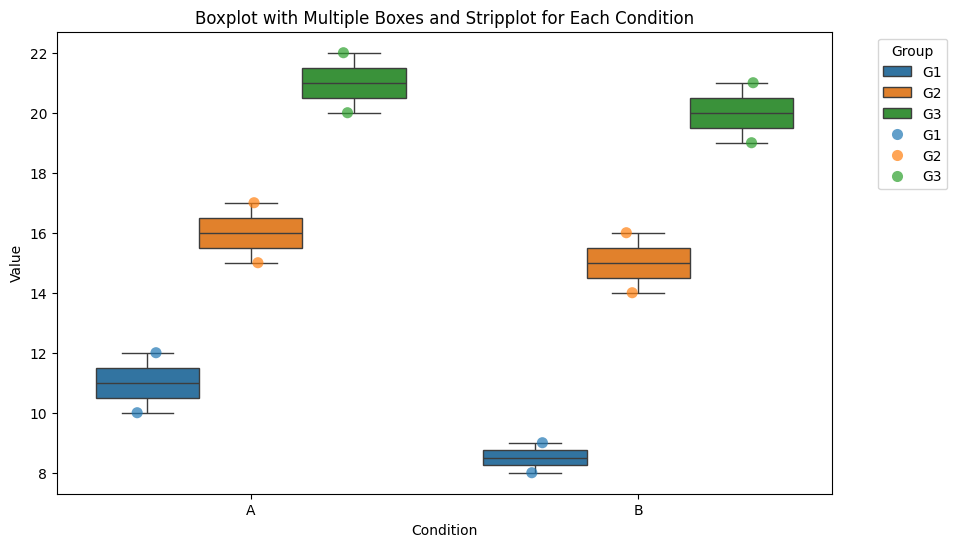

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Example DataFrame
data = {
    'Condition': ['A', 'A', 'A', 'A', 'A', 'A', 
                  'B', 'B', 'B', 'B', 'B', 'B'],
    'Group': ['G1', 'G1', 'G2', 'G2', 'G3', 'G3',
              'G1', 'G1', 'G2', 'G2', 'G3', 'G3'],
    'Value': [10, 12, 15, 17, 20, 22, 
              8, 9, 14, 16, 19, 21]
}
df = pd.DataFrame(data)

# Plot boxplot and stripplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Condition', y='Value', hue='Group', data=df, dodge=True, whis=1.5)
sns.stripplot(x='Condition', y='Value', hue='Group', data=df, dodge=True, jitter=True, size=8, marker='o', alpha=0.7)

# Adjust legend and aesthetics
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Boxplot with Multiple Boxes and Stripplot for Each Condition")
plt.xlabel("Condition")
plt.ylabel("Value")
plt.show()


In [3]:
df

,Condition,Group,Value
0,A,G1,10
1,A,G1,12
2,A,G2,15
3,A,G2,17
4,A,G3,20
5,A,G3,22
6,B,G1,8
7,B,G1,9
8,B,G2,14
9,B,G2,16


In [2]:
pg=pd.read_csv(r'C:/Users/jiangy5/Box/macrophage-33files/macro-repeat-33-v1.pg_matrix.tsv', sep='\t')

Take log10 to the raw value and then made a SS again to the dataset

In [3]:
pg.set_index('Protein.Ids',inplace=True)

In [4]:
#pg

In [5]:
number_pro_each=[]

for column_id in range(4,34):
    
    number_pro_each.append(len([item for item in pg.iloc[:,column_id] if not pd.isna(item)]))
    
#number_pro_each    

(array([ 1.,  2.,  2.,  2.,  2.,  1.,  3.,  2.,  4., 11.]),
 array([6647. , 6675.8, 6704.6, 6733.4, 6762.2, 6791. , 6819.8, 6848.6,
        6877.4, 6906.2, 6935. ]),
 <BarContainer object of 10 artists>)

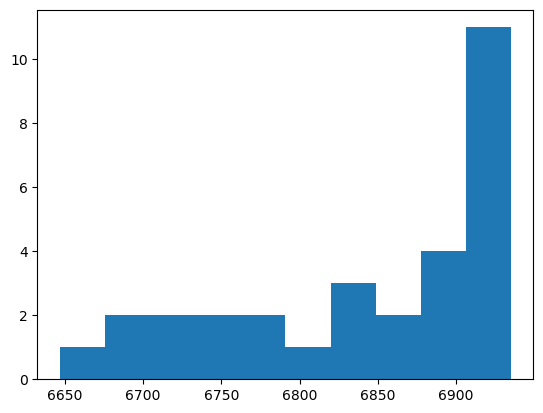

In [7]:
plt.hist(number_pro_each)

In [9]:
pro_quan=pg.iloc[:,4:]

pglog10=np.log10(pro_quan) # take all protein raw values out and take log10 to the dataset


In [10]:
pglog10.columns=range(1,34)    # rename column names

In [11]:
pglog10

,1,2,3,4,5,6,7,8,9,10,...,24,25,26,27,28,29,30,31,32,33
Protein.Ids,,,,,,,,,,,,,,,,,,,,,
A0A991ENX0;M0QWR4;M0QWS9;K9J7E2;E9PZY4;A0A3B2W7J0;A0A087WNP0;B2RY52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.252368,NaN,5.113542,5.313620,NaN,NaN,NaN,5.254744,NaN,NaN
A0A087WQ44,6.158902,6.069265,6.060732,6.040867,6.107274,6.192514,6.073051,6.190950,6.164389,6.256646,...,6.096489,6.135126,6.047150,6.081876,6.271049,6.208347,6.196629,6.175778,6.163060,6.148812
A0A087WRT7,NaN,NaN,NaN,NaN,5.398659,NaN,NaN,5.945553,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.102300
A0A0B4J1G0,6.294215,6.411536,6.270225,6.227884,6.387909,6.371144,6.961961,6.945998,6.960637,6.975026,...,6.556694,6.475484,6.522867,6.525654,7.162260,7.214621,7.075408,6.496580,6.558543,6.441756
A0A0G2JDV3,6.085826,6.167500,6.120834,6.117089,6.369537,6.180390,6.569058,6.678339,6.575853,6.610852,...,6.370968,6.349256,6.271240,6.373307,6.797520,6.855830,6.724828,6.415267,6.354564,6.417050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9Z306,5.489092,5.532474,5.556886,5.524049,5.579351,5.625558,5.420995,5.378053,5.608298,5.493946,...,5.700112,5.789273,5.697645,5.786429,5.762901,5.636591,5.805244,5.666734,5.519516,5.588588
Q9Z315,6.625311,6.641428,6.630053,6.563552,6.664165,6.607368,6.558355,6.684700,6.629626,6.646449,...,6.656346,6.643711,6.685055,6.661381,6.690253,6.668209,6.676881,6.717328,6.652129,6.682409
Q9Z321,6.438963,6.468989,6.528926,6.425130,6.516352,6.443285,6.484377,6.498568,6.410095,6.436204,...,6.314546,6.417021,6.485293,6.415478,6.376739,6.370124,6.362467,6.443527,6.405894,6.467873


In [12]:
dflog10=pglog10.iloc[:,:18].dropna()       # take the three treatments out

In [13]:
#dflog10

In [14]:
import math
import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# StandardScaler analysis starts here 

In [15]:
ss = StandardScaler() 
dflog10_ss = ss.fit_transform(dflog10)

In [16]:
dflog10_ss_ed=pd.DataFrame(dflog10_ss,index=dflog10.index,columns=dflog10.columns)

In [17]:
dflog10_ss_ed

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Protein.Ids,,,,,,,,,,,,,,,,,,
A0A087WQ44,-1.006330,-1.171650,-1.163112,-1.178069,-1.119791,-0.973701,-1.149281,-0.984942,-1.011816,-0.903258,-1.029692,-0.985846,-1.067750,-0.972635,-1.123182,-1.126251,-1.148039,-1.131624
A0A0B4J1G0,-0.805645,-0.662549,-0.853897,-0.901058,-0.703394,-0.705585,0.179974,0.125694,0.193275,0.172849,0.198536,0.164614,-0.728154,-0.687995,-0.752206,-0.636794,-0.790958,-0.613446
A0A0G2JDV3,-1.114712,-1.025532,-1.074400,-1.065169,-0.730655,-0.991900,-0.407564,-0.268018,-0.389081,-0.372671,-0.436602,-0.508532,-0.900006,-0.888740,-0.833897,-0.821858,-0.735902,-0.799840
A0A0G2JG52,-1.439966,-1.415878,-1.141104,-1.689046,-1.621473,-1.331965,-0.982345,-0.868677,-0.739584,-0.781386,-0.794291,-0.636597,-1.070879,-1.733733,-1.131422,-1.648147,-1.197697,-1.731252
A0A0J9YTR2,-0.296377,-0.481406,-0.296299,-0.277059,-0.430798,-0.423022,-0.381322,-0.491034,-0.493354,-0.616689,-0.439682,-0.446055,-0.289413,-0.332986,-0.338867,-0.287613,-0.366177,-0.245297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9Z306,-1.999742,-1.970086,-1.906796,-1.943583,-1.903106,-1.824683,-2.124349,-2.180674,-1.853438,-2.045755,-2.084062,-2.094360,-1.819312,-1.923488,-1.782654,-1.762553,-1.788774,-2.042066
Q9Z315,-0.314587,-0.320600,-0.322784,-0.403864,-0.293495,-0.351020,-0.423570,-0.258661,-0.307697,-0.319347,-0.310744,-0.336938,-0.252419,-0.275262,-0.330478,-0.311815,-0.335585,-0.273456
Q9Z321,-0.590965,-0.577090,-0.472050,-0.608896,-0.512816,-0.597304,-0.534194,-0.532452,-0.639948,-0.634286,-0.588454,-0.508664,-0.533631,-0.542045,-0.560286,-0.538946,-0.595944,-0.597266


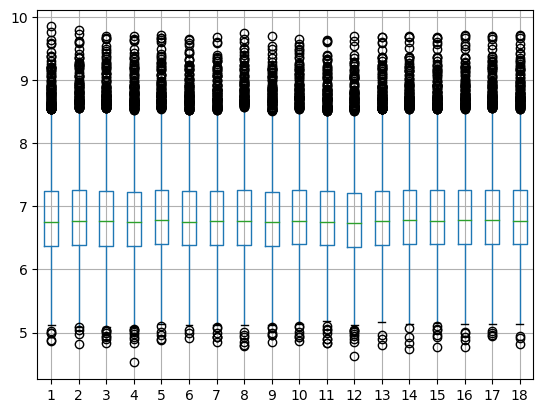

In [18]:
dflog10.boxplot()
plt.show()

<AxesSubplot:>

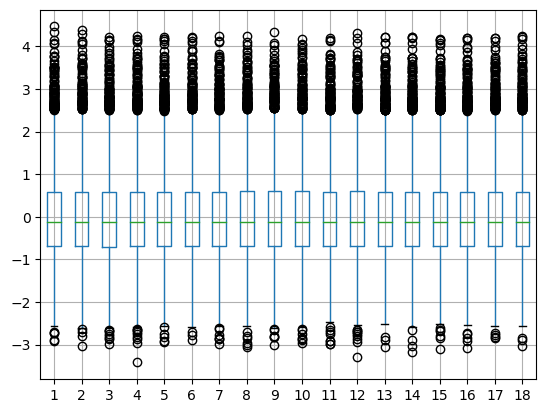

In [19]:
dflog10_ss_ed.boxplot()

In [20]:

def oneway_ANOVA(result_df):
    '''input file type is Dataframe, output file is 
    a datafram with pvalues and corresponding P_values of each row'''
    pval=[]
    for i in range(len(result_df)):
        aa=result_df.iloc[i,:6].tolist()
        bb=result_df.iloc[i,6:12].tolist()
        cc=result_df.iloc[i,12:18].tolist()
        p_value=f_oneway(aa,bb,cc)[1]
        pro_name=dflog10_ss_ed.index[i]
        pval.append([i,pro_name,p_value])
        fl = pd.DataFrame(pval)
        fl.columns = ['number','proname', 'p_value']

    return(fl)

In [21]:
df_pval=oneway_ANOVA(dflog10_ss_ed)

In [22]:
len([item for item in df_pval['p_value'].tolist() if item <0.05])

3904

In [23]:
# FDR correction for all p_values from Standard scaler
FDR_res=statsmodels.stats.multitest.fdrcorrection(df_pval['p_value'].tolist(), alpha=0.05, method='indep', is_sorted=False)[0]

In [24]:
# calculate the pvalues < 0.05 after FDR correction 
yuyu=[]
for item in range(len(FDR_res)):
    if FDR_res[item]== True:
        yuyu.append(item)
len(yuyu)

3639

In [25]:
df_pval[df_pval['number'].isin(yuyu)]

,number,proname,p_value
1,1,A0A0B4J1G0,2.937222e-13
2,2,A0A0G2JDV3,7.194545e-08
3,3,A0A0G2JG52,2.253780e-04
4,4,A0A0J9YTR2,3.826070e-03
5,5,A0A140LIF8,5.591349e-12
...,...,...,...
5858,5858,Q9Z2W1,6.963779e-04
5861,5861,Q9Z2X8,1.249087e-04
5862,5862,Q9Z2Y8,3.240399e-03
5864,5864,Q9Z306,6.070012e-03


In [38]:
df_sig=dflog10_ss_ed.iloc[yuyu]

In [39]:
# 按行进行标准归一化

scaler=StandardScaler()
proname=df_sig.T.columns
k=df_sig.T
dfdf_pro=ss.fit_transform(k)
# 按行进行标准化后的 dataframe
dfpro_stdbyrow=pd.DataFrame(dfdf_pro.T,index=df_sig.index,columns=df_sig.columns)
dfpro_stdbyrow

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Protein.Ids,,,,,,,,,,,,,,,,,,
A0A0B4J1G0,-0.856470,-0.526959,-0.967582,-1.076181,-0.621015,-0.626060,1.413143,1.288151,1.443773,1.396736,1.455887,1.377772,-0.678031,-0.585554,-0.733416,-0.467653,-0.822651,-0.413890
A0A0G2JDV3,-1.381419,-1.050436,-1.231805,-1.197544,0.043979,-0.925614,1.243104,1.761019,1.311704,1.372609,1.135333,0.868370,-0.584557,-0.542742,-0.339197,-0.294515,0.024505,-0.212797
A0A0G2JG52,-0.609403,-0.542747,0.217625,-1.298674,-1.111682,-0.310537,0.656954,0.971502,1.328737,1.213057,1.177346,1.613727,0.411956,-1.422334,0.244418,-1.185494,0.061017,-1.415470
A0A0J9YTR2,0.922259,-0.999099,0.923068,1.122860,-0.473575,-0.392833,0.040180,-1.099071,-1.123167,-2.403889,-0.565835,-0.632009,0.994569,0.542104,0.481040,1.013265,0.197452,1.452680
A0A140LIF8,-1.016197,-0.821855,-1.302935,-0.520303,-0.787514,-0.928488,1.352753,1.537478,1.217799,1.538867,1.364835,1.209293,-0.572194,-0.296277,-0.412267,-0.305107,-0.598915,-0.658972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9Z2W1,-0.066242,-0.642432,1.086455,1.551417,-0.069650,0.608465,1.021986,0.628354,-0.090584,0.503515,0.746473,1.336444,-1.553708,-1.848581,-1.464563,-0.811258,0.033817,-0.969909
Q9Z2X8,-0.329620,-1.275137,-2.076348,-1.223046,-0.981090,-1.181553,0.292852,1.139813,1.523705,-0.021927,1.189486,-0.085927,0.655505,0.963679,0.287076,1.155407,-0.327944,0.295069
Q9Z2Y8,0.128842,1.688265,1.338355,0.773857,1.121794,1.110083,-0.304399,0.048778,-1.693412,-0.041693,-0.048871,-1.660248,-2.060297,-0.210040,-0.342426,-0.138431,0.320716,-0.030875


In [40]:
# use the mean value of each treatment 

df=dfpro_stdbyrow
#calculate the mean value from 6 repeats in each treatment

M0=df.iloc[:,:6].mean(axis=1).tolist()
M1=df.iloc[:,6:12].mean(axis=1).tolist()
M2=df.iloc[:,12:18].mean(axis=1).tolist()

newdict={'Con_M0':M0,'LPS_M1':M1,'IL_4_M2':M2}

df_mean=pd.DataFrame.from_dict(newdict)
df_mean.index=df.index
df_mean

,Con_M0,LPS_M1,IL_4_M2
Protein.Ids,,,
A0A0B4J1G0,-0.779045,1.395910,-0.616866
A0A0G2JDV3,-0.957139,1.282023,-0.324884
A0A0G2JG52,-0.609236,1.160221,-0.550985
A0A0J9YTR2,0.183780,-0.963965,0.780185
A0A140LIF8,-0.896216,1.370171,-0.473955
...,...,...,...
Q9Z2W1,0.411336,0.691031,-1.102367
Q9Z2X8,-1.177799,0.673000,0.504799
Q9Z2Y8,1.026866,-0.616641,-0.410225


In [35]:
df=df_mean

selected_rows_ = df[df.apply(lambda row: row['LPS_M1'] == row.max(), axis=1)]

In [36]:
selected_rows.to_csv(r')

,Con_M0,LPS_M1,IL_4_M2
Protein.Ids,,,
A0A0B4J1G0,-0.772021,0.172490,-0.701592
A0A0G2JDV3,-1.000395,-0.397078,-0.830041
A0A0G2JG52,-1.439905,-0.800480,-1.418855
A0A140LIF8,-1.142246,-0.006170,-0.930578
A0A140LIF8;Q9DCE9,-1.295872,-0.117378,-1.246662
...,...,...,...
Q9Z2L6,-0.843624,-0.543062,-0.886816
Q9Z2L7,-0.274161,-0.061541,-0.239159
Q9Z2W1,-0.542499,-0.516206,-0.684799


In [46]:
def optimise_k_means(data,max_k):
    means=[]
    inertias=[]
    for k in range(1,max_k):
        kmeans=KMeans(n_clusters=k)
        kmeans.fit(data)
        means.append(k)
        inertias.append(kmeans.inertia_)
    fig=plt.subplots(figsize=(10,5))
    plt.plot(means,inertias)
    plt.xlabel('number of clusters')
    plt.ylabel('inertia')
    plt.show()

In [47]:
kmeans=KMeans(n_clusters=5)
kmeans.fit(df_mean[['Con_M0','LPS_M1','IL_4_M2']])

df_mean['kmeans']=kmeans.labels_
df_mean

,Con_M0,LPS_M1,IL_4_M2,kmeans
Protein.Ids,,,,
A0A0B4J1G0,-0.779045,1.395910,-0.616866,2
A0A0G2JDV3,-0.957139,1.282023,-0.324884,2
A0A0G2JG52,-0.609236,1.160221,-0.550985,2
A0A0J9YTR2,0.183780,-0.963965,0.780185,0
A0A140LIF8,-0.896216,1.370171,-0.473955,2
...,...,...,...,...
Q9Z2W1,0.411336,0.691031,-1.102367,3
Q9Z2X8,-1.177799,0.673000,0.504799,2
Q9Z2Y8,1.026866,-0.616641,-0.410225,1


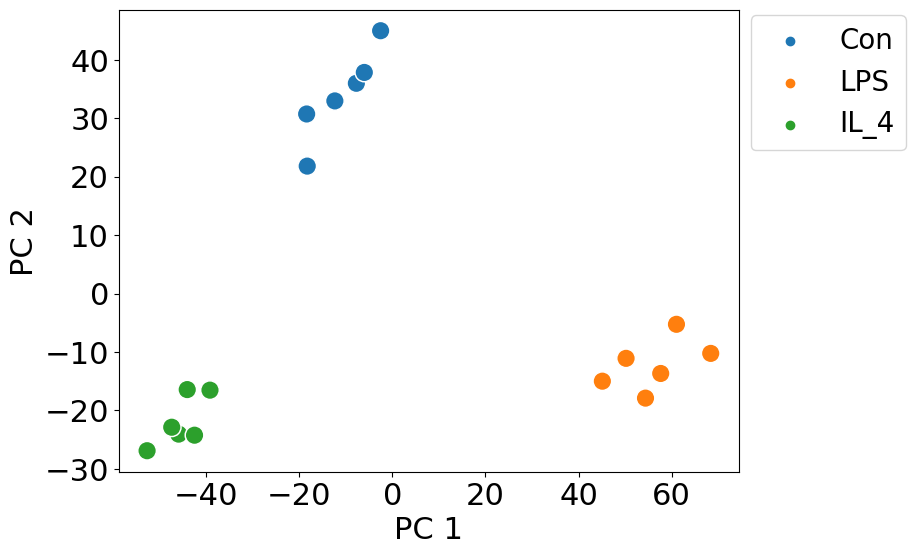

In [27]:
# set the data soucrce
df =dflog10_ss_ed.iloc[yuyu].T
treatment=['Con']*6+['LPS']*6+['IL_4']*6
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# perform PCA with 2 principal components
pca = PCA(n_components=2)
pca.fit(X_scaled)

# transform the features to the new space
X_pca = pca.transform(X_scaled)

# create a new dataframe with the principal components and target variable
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = treatment

# plot the results
import seaborn as sns
plt.figure(figsize=(8, 6), edgecolor='#04253a')
sns.scatterplot(x='PC1', y='PC2', hue='target', data=df_pca, s=180)
plt.yticks(fontsize=22)
plt.xticks(fontsize=22)
plt.xlabel('PC 1', fontsize=22)
plt.ylabel('PC 2', fontsize=22)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.2,fontsize=20)

(array([0.5, 1.5, 2.5]),
 [Text(0, 0.5, 'Con_M0'), Text(0, 1.5, 'LPS_M1'), Text(0, 2.5, 'IL_4_M2')])

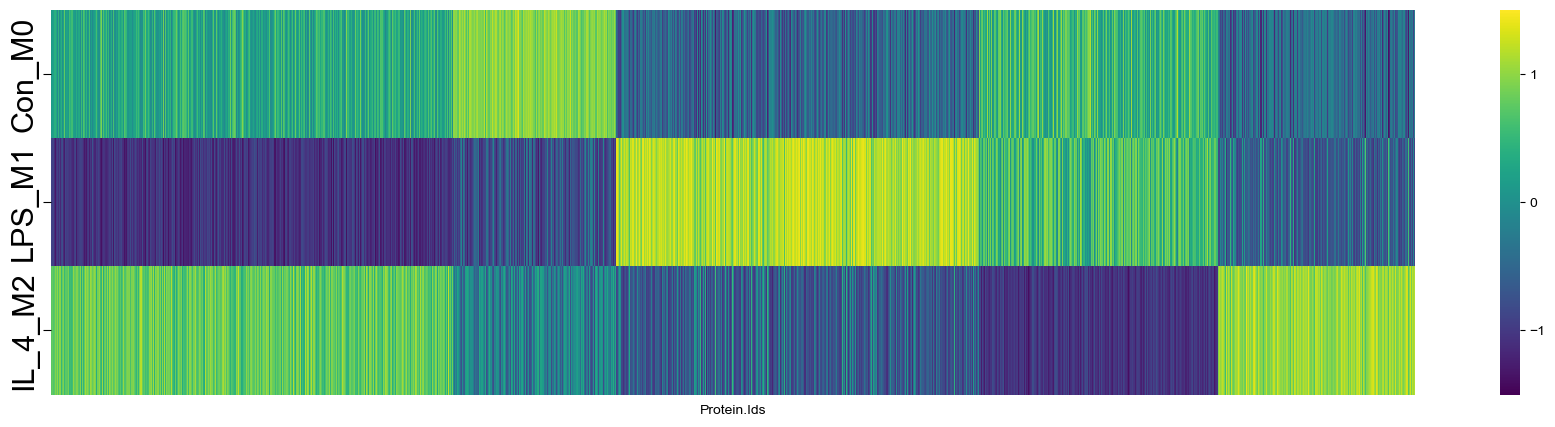

In [48]:
df_df=df_mean
dfaa=df_df.sort_values(by='kmeans')
df_bb=dfaa.T
df_heat=df_bb.iloc[:3,:]

plt.figure(figsize=(22,5),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"
sns.heatmap(df_heat,  vmin=-1.5, vmax=1.5,cmap='viridis',xticklabels=False,cbar_kws={"shrink": 1, 'ticks': [-2, -1, 0, 1, 2]})
plt.xticks([])
plt.yticks()
plt.tick_params(axis='y',length=6)
plt.yticks(rotation=90)
plt.yticks(fontsize=22)

In [53]:
x=['Con','LPS','IL_4']
sigpro_stdrow=df_mean
# take different cluster protein names out
sig_cluster4=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==4]
sig_cluster3=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==3]
sig_cluster2=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==2]
sig_cluster1=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==1]
sig_cluster0=sigpro_stdrow.loc[sigpro_stdrow['kmeans']==0]

In [54]:
[len(sig_cluster0),len(sig_cluster1),len(sig_cluster2),len(sig_cluster3),len(sig_cluster4),]

[1071, 435, 968, 638, 527]

In [56]:
sig_cluster4.to_csv(r'C:/Users/jiangy5/Box/macrophage-33files/analysis/cluster4.csv')

In [57]:
sig_cluster3.to_csv(r'C:/Users/jiangy5/Box/macrophage-33files/analysis/cluster3.csv')
sig_cluster2.to_csv(r'C:/Users/jiangy5/Box/macrophage-33files/analysis/cluster2.csv')
sig_cluster1.to_csv(r'C:/Users/jiangy5/Box/macrophage-33files/analysis/cluster1.csv')
sig_cluster0.to_csv(r'C:/Users/jiangy5/Box/macrophage-33files/analysis/cluster0.csv')

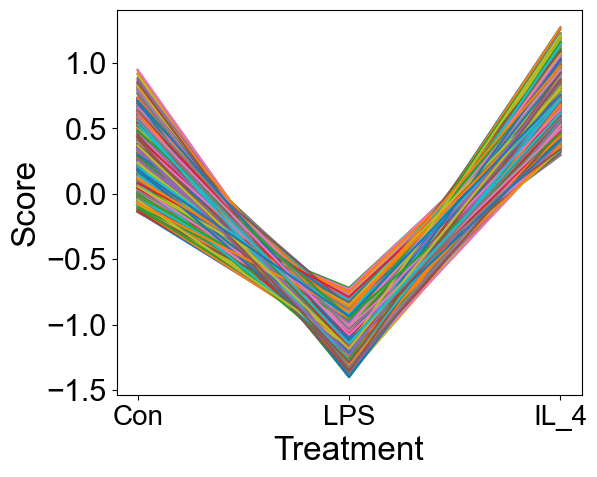

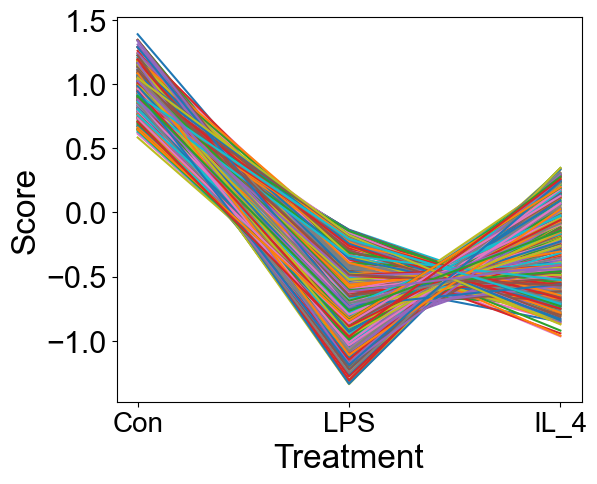

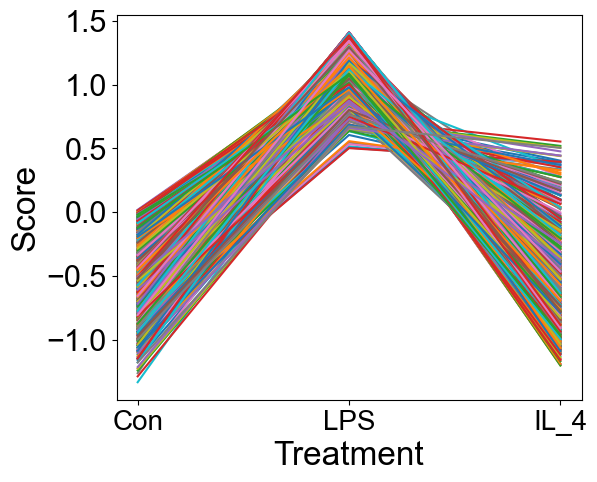

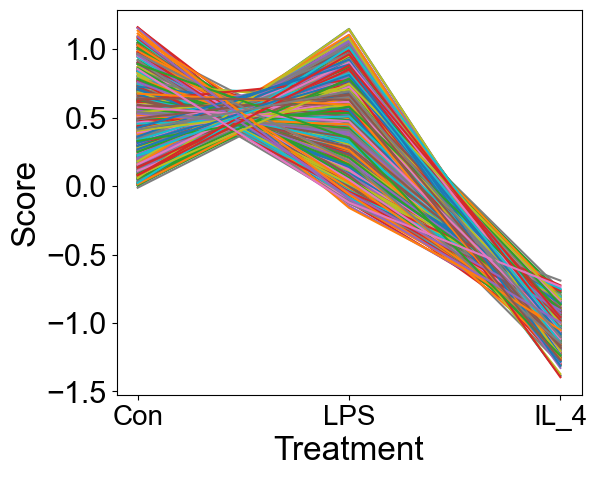

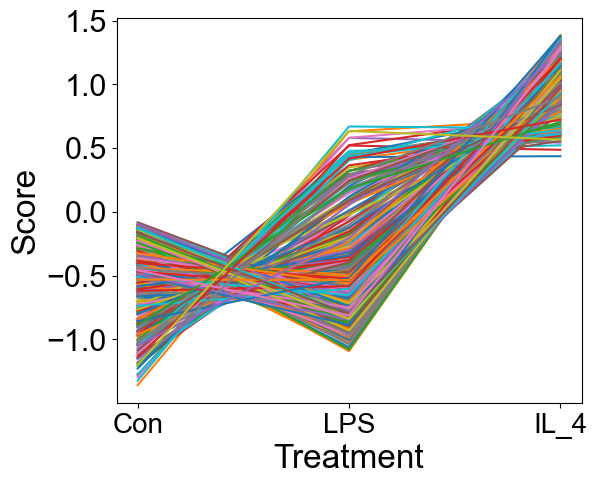

In [50]:
import matplotlib.pyplot as plt

# Create a dictionary of cluster names and corresponding data
cluster_data = {'sigpro_Cluster 1': sigpro_stdrow.loc[list(sig_cluster0.index)],
                'sigpro_Cluster 2': sigpro_stdrow.loc[list(sig_cluster1.index)],
                'sigpro_Cluster 3': sigpro_stdrow.loc[list(sig_cluster2.index)],
                'sigpro_Cluster 4': sigpro_stdrow.loc[list(sig_cluster3.index)],
                'sigpro_Cluster 5': sigpro_stdrow.loc[list(sig_cluster4.index)]}

# Loop over the dictionary items to plot the data for each cluster
for title, data in cluster_data.items():
    plt.figure(figsize=(6, 5), edgecolor='#04253a')
    plt.rcParams['font.family'] = 'Arial'
    for i in range(len(data)):
        plt.plot(x, data.iloc[i, :3])  
    #plt.title(title, fontsize=24)
    plt.xlabel('Treatment', fontsize=24)
    plt.ylabel('Score', fontsize=24)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=22)
    #plt.savefig(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\SI_figures\\{}.svg'.format(title),dpi=800,bbox_inches='tight')
    plt.show()

In [142]:
df

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Protein.Ids,,,,,,,,,,,,,,,,,,
A0A0B4J1G0,-0.805645,-0.662549,-0.853897,-0.901058,-0.703394,-0.705585,0.179974,0.125694,0.193275,0.172849,0.198536,0.164614,-0.728154,-0.687995,-0.752206,-0.636794,-0.790958,-0.613446
A0A0G2JDV3,-1.114712,-1.025532,-1.074400,-1.065169,-0.730655,-0.991900,-0.407564,-0.268018,-0.389081,-0.372671,-0.436602,-0.508532,-0.900006,-0.888740,-0.833897,-0.821858,-0.735902,-0.799840
A0A0G2JG52,-1.439966,-1.415878,-1.141104,-1.689046,-1.621473,-1.331965,-0.982345,-0.868677,-0.739584,-0.781386,-0.794291,-0.636597,-1.070879,-1.733733,-1.131422,-1.648147,-1.197697,-1.731252
A0A0J9YTR2,-0.296377,-0.481406,-0.296299,-0.277059,-0.430798,-0.423022,-0.381322,-0.491034,-0.493354,-0.616689,-0.439682,-0.446055,-0.289413,-0.332986,-0.338867,-0.287613,-0.366177,-0.245297
A0A140LIF8,-1.202389,-1.104971,-1.346123,-0.953811,-1.087757,-1.158423,-0.014901,0.077696,-0.082550,0.078392,-0.008845,-0.086814,-0.979823,-0.841513,-0.899656,-0.845940,-0.993217,-1.023322
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9Z2W1,-0.587395,-0.641562,-0.479033,-0.435323,-0.587716,-0.523968,-0.485093,-0.522098,-0.589684,-0.533834,-0.510994,-0.455532,-0.727229,-0.754949,-0.718849,-0.657433,-0.577989,-0.672347
Q9Z2X8,-0.209926,-0.241066,-0.267453,-0.239350,-0.231381,-0.237984,-0.189425,-0.161530,-0.148887,-0.199792,-0.159894,-0.201900,-0.177481,-0.167331,-0.189615,-0.161017,-0.209870,-0.189352
Q9Z2Y8,0.806642,0.885405,0.867731,0.839220,0.856793,0.856202,0.784760,0.802598,0.714604,0.798028,0.797666,0.716279,0.696073,0.789525,0.782839,0.793142,0.816333,0.798575


In [59]:
df_glycolysis=pd.read_excel(r'C:/Users/jiangy5/Box/macrophage-33files/analysis/uniprotkb_glycolysis_AND_model_organism_2024_02_09.xlsx')

C:\Users\jiangy5\Anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [65]:
len(df_glycolysis['Entry'].tolist())

214

In [64]:
len(df_glycolysis['Protein names'].tolist())

214

In [68]:
entries = df_glycolysis['Entry'].tolist()
protein_names = df_glycolysis['Protein names'].tolist()

# Now, zip these lists together
zipped_list = [(x, y) for x, y in zip(entries, protein_names)]

In [97]:
for item in zipped_list:
    if item[0] in list(overlap):

'A0A1D5RLD8'

In [71]:
#zipped_list

In [84]:
overlap=set(dfpro_stdbyrow.index.tolist())& set(entries)

In [94]:
#list(overlap)

In [100]:
find_tuple_by_first_value(zipped_list, list(overlap)[0])

('P17809',
 'Solute carrier family 2, facilitated glucose transporter member 1 (Glucose transporter type 1, erythrocyte/brain) (GLUT-1) (GT1)')

In [93]:
#dfpro_stdbyrow

In [99]:
treatment=['Con_']*6+['LPS']*6+['IL-4']*6

def getdf(name='P17809',df=dfpro_stdbyrow):    
    A=df.iloc[:,:6].loc[name].to_frame()
    A.columns=['Value']  
    B=df.iloc[:,6:12].loc[name].to_frame()
    B.columns=['Value']   
    C=df.iloc[:,12:18].loc[name].to_frame()
    C.columns=['Value'] 
    made=pd.concat([A,B,C])
    made['treatment'] = treatment
    return(made)
def find_tuple_by_first_value(tuples_list, value):
    for item in tuples_list:
        if item[0] == value:
            return item
    return None

In [98]:
#getdf(name='P17809',df=dfpro_stdbyrow)

In [116]:

def plot_fig(number='proname',df_name=dfpro_stdbyrow,
            fig_path = 'C:/Users/jiangy5/Box/macrophage-33files/analysis/'):  
    plt.figure(figsize=(7,7))
    dataset=getdf(name=number,df=df_name)
    #palette = ['#9B3A4D', '#E2AE79', '#497EB2','#D0DCAA', '#8CBDA7', '#68AC57','#70A0AC']
    ax = sns.boxplot(x="treatment", y="Value",width=0.8, data=dataset,palette='viridis')
    ax = sns.stripplot(x="treatment", y="Value", data=dataset, color="black",size=12)
    ax.set_xlabel("")
    ax.set_ylabel("Score", fontsize=36)
    ax.tick_params(axis='both', labelsize=35)
    ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
    plt.title(find_tuple_by_first_value(zipped_list, number))
    plt.savefig(os.path.join(fig_path, f"{number}.png"), dpi=300, bbox_inches='tight')
    plt.show()

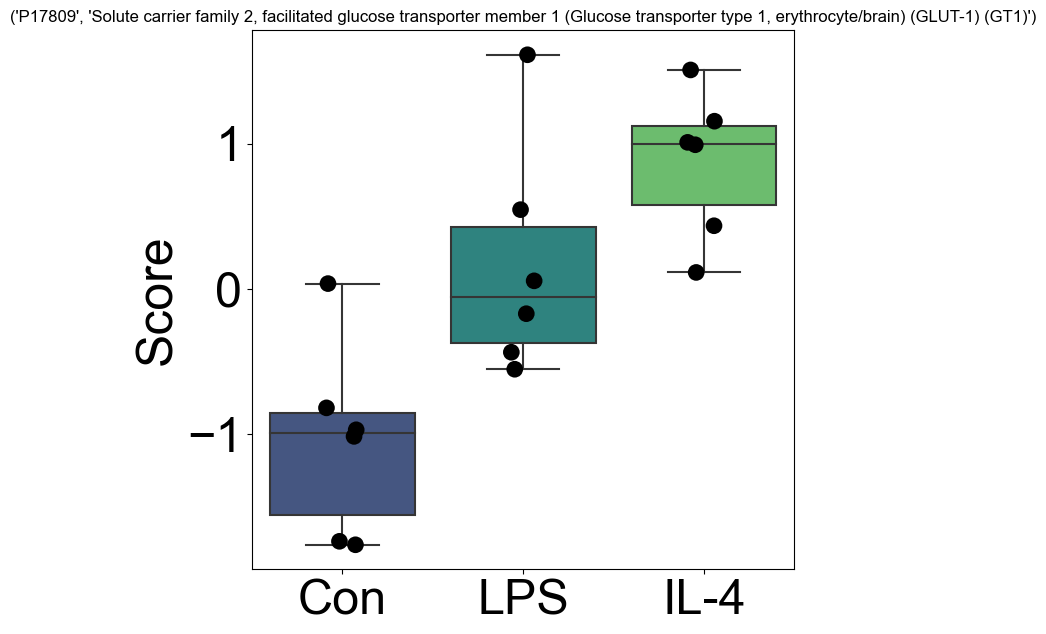

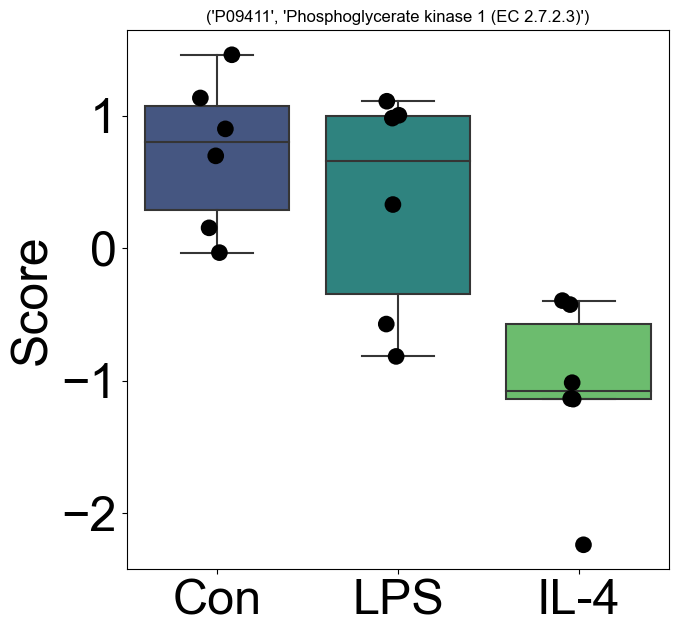

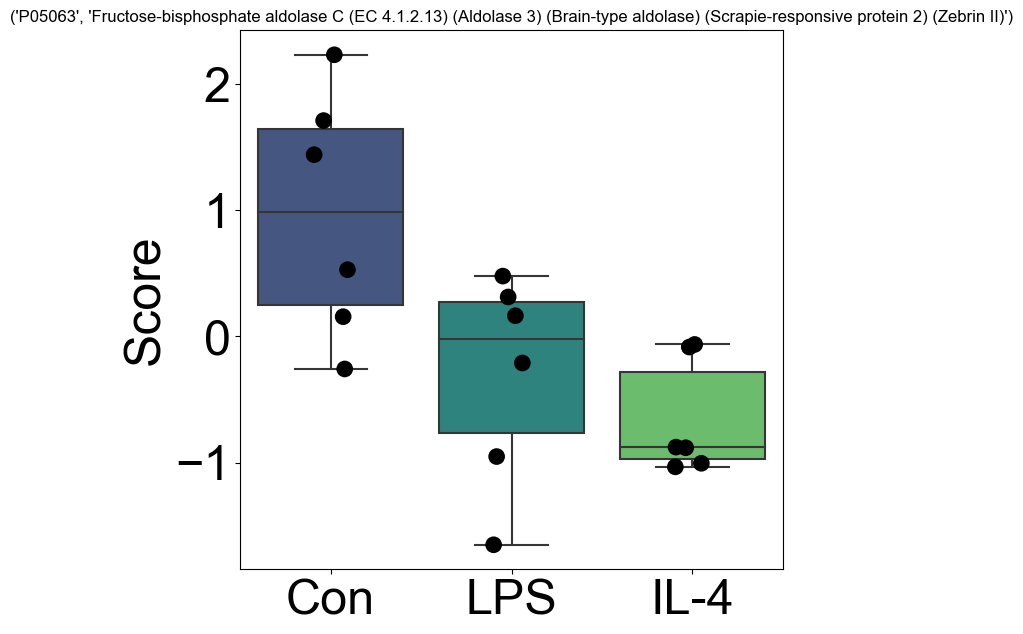

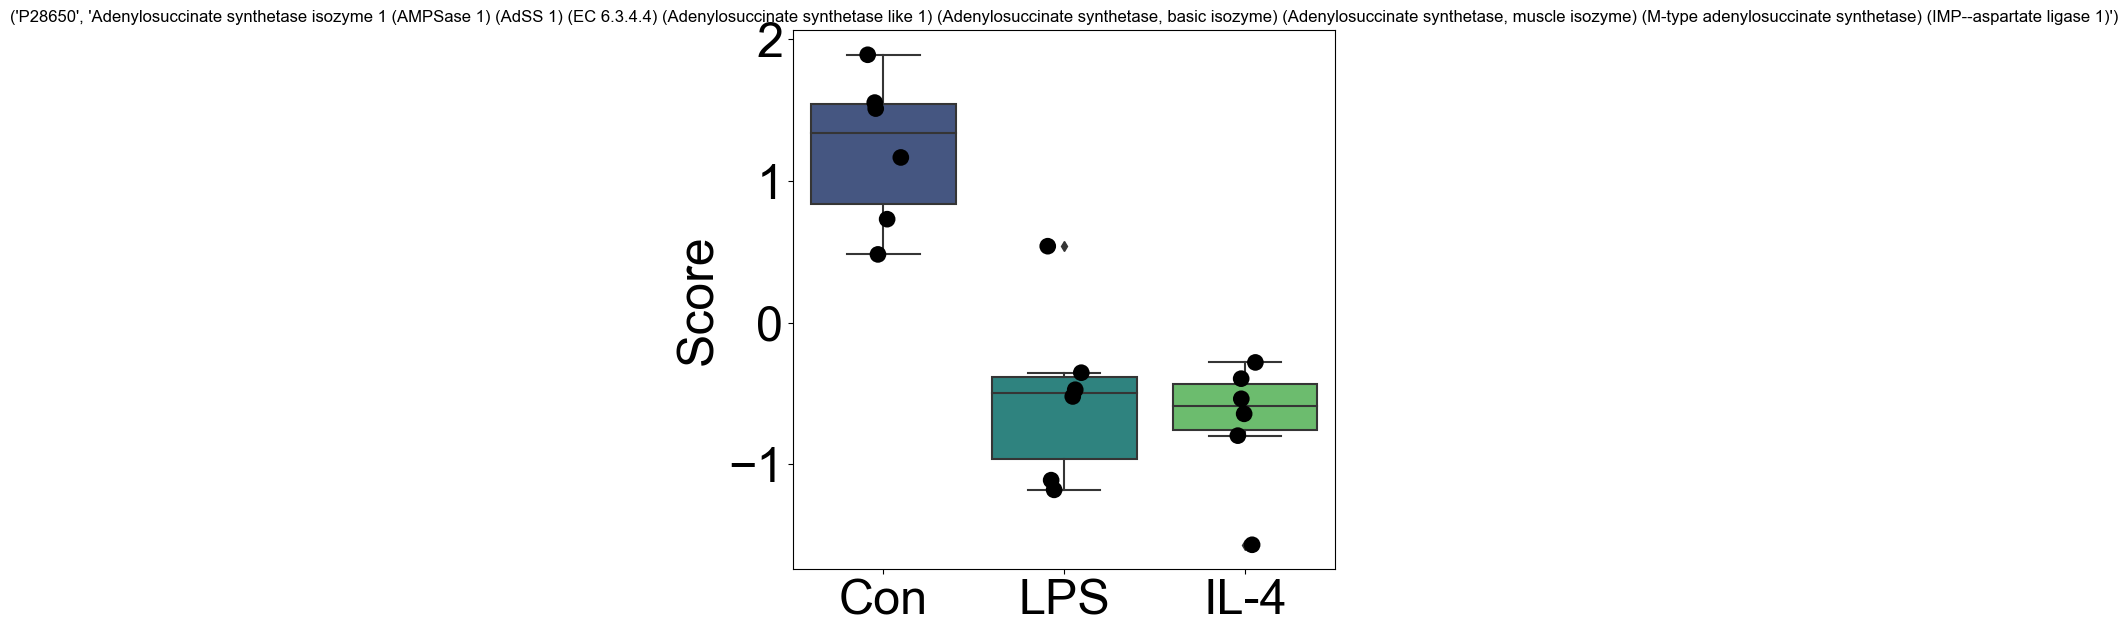

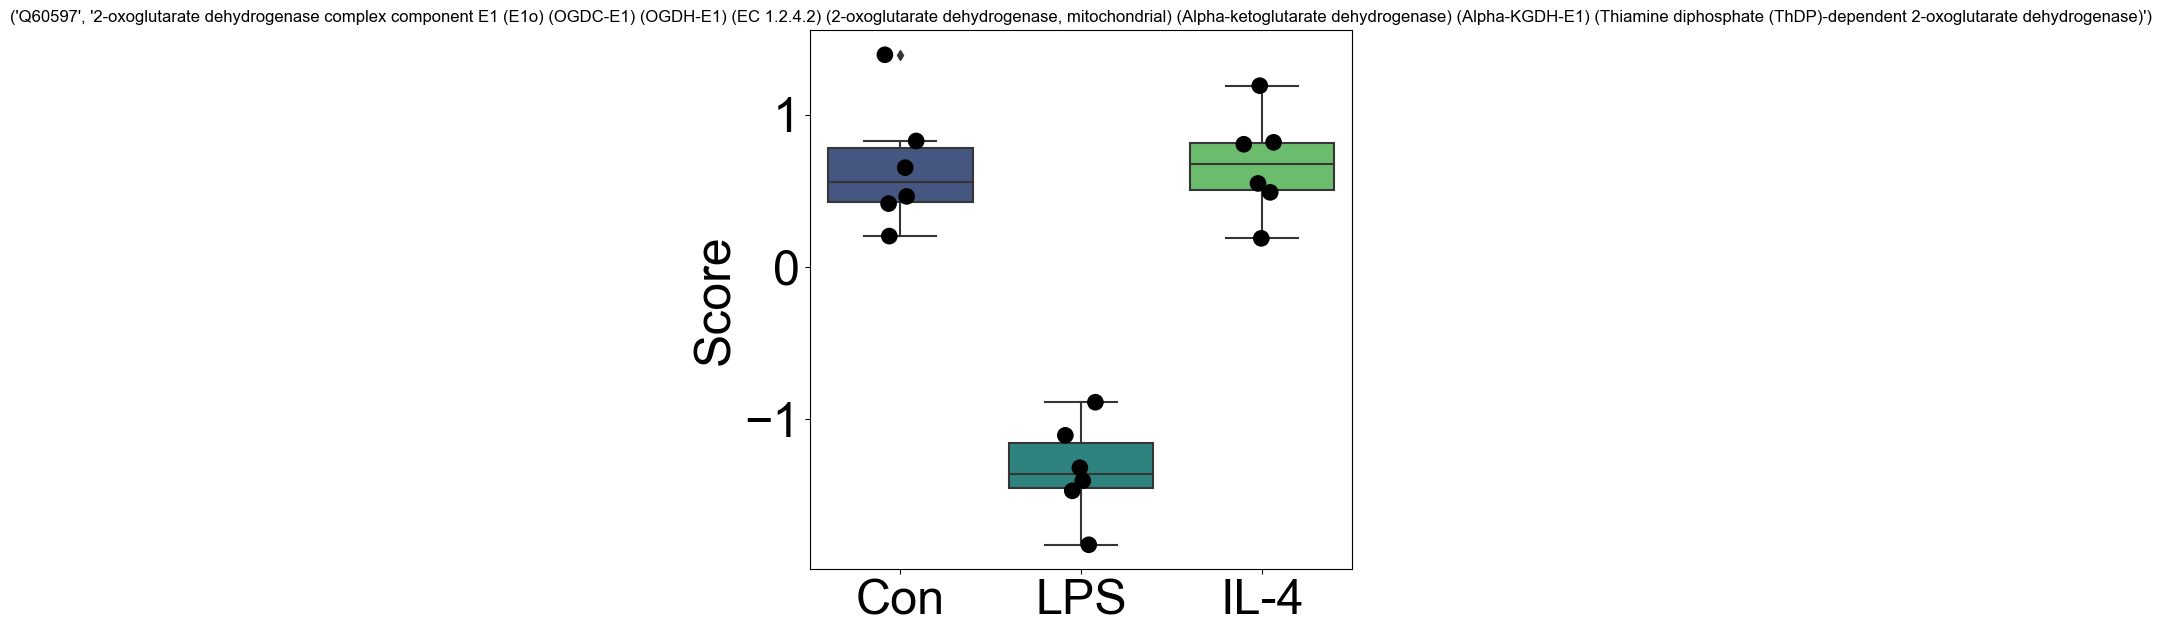

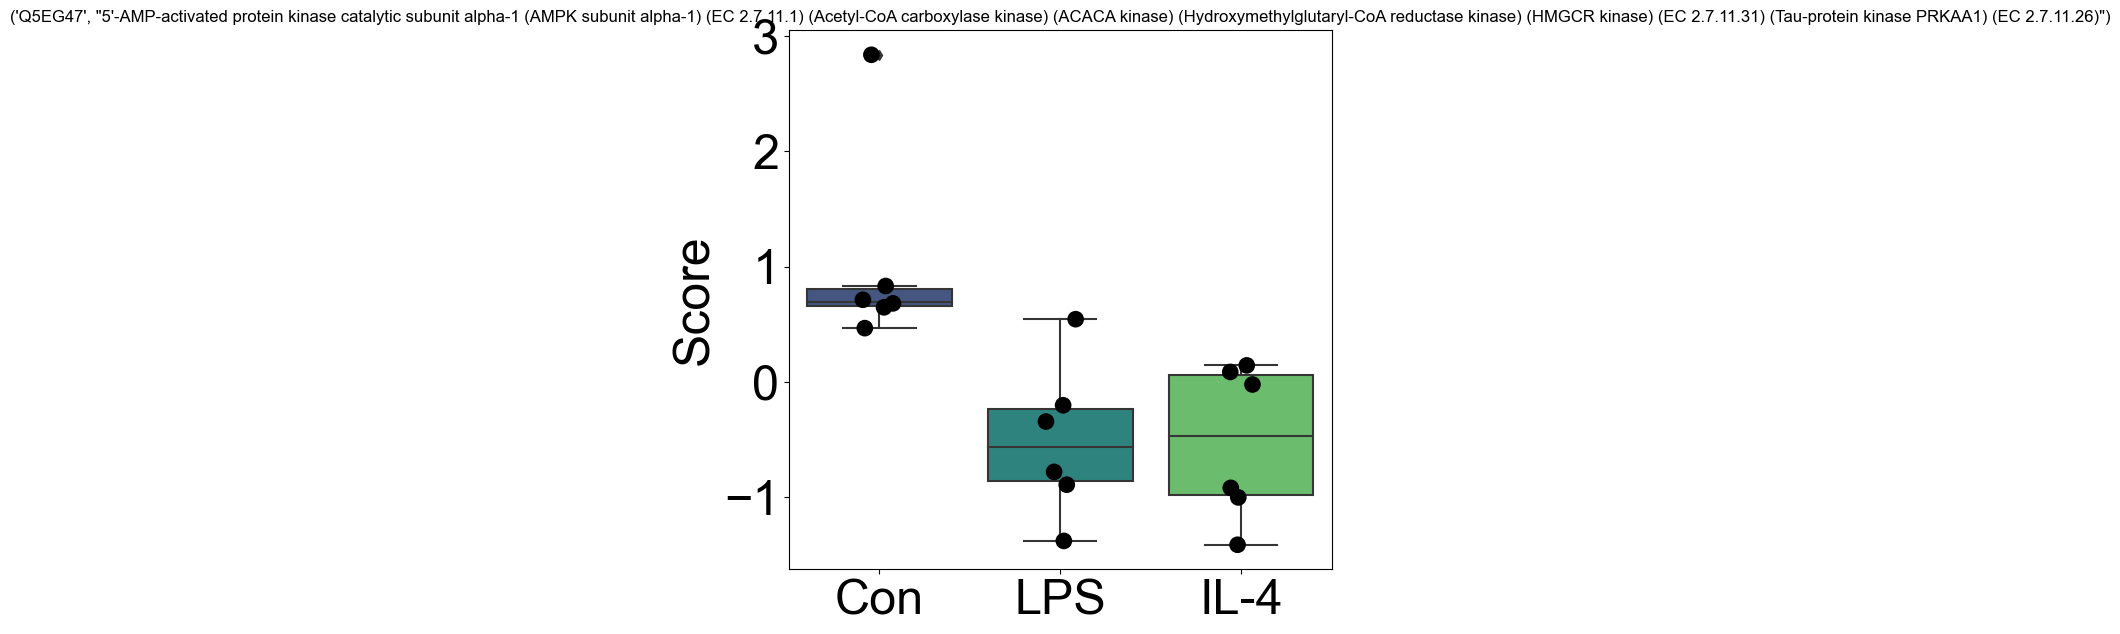

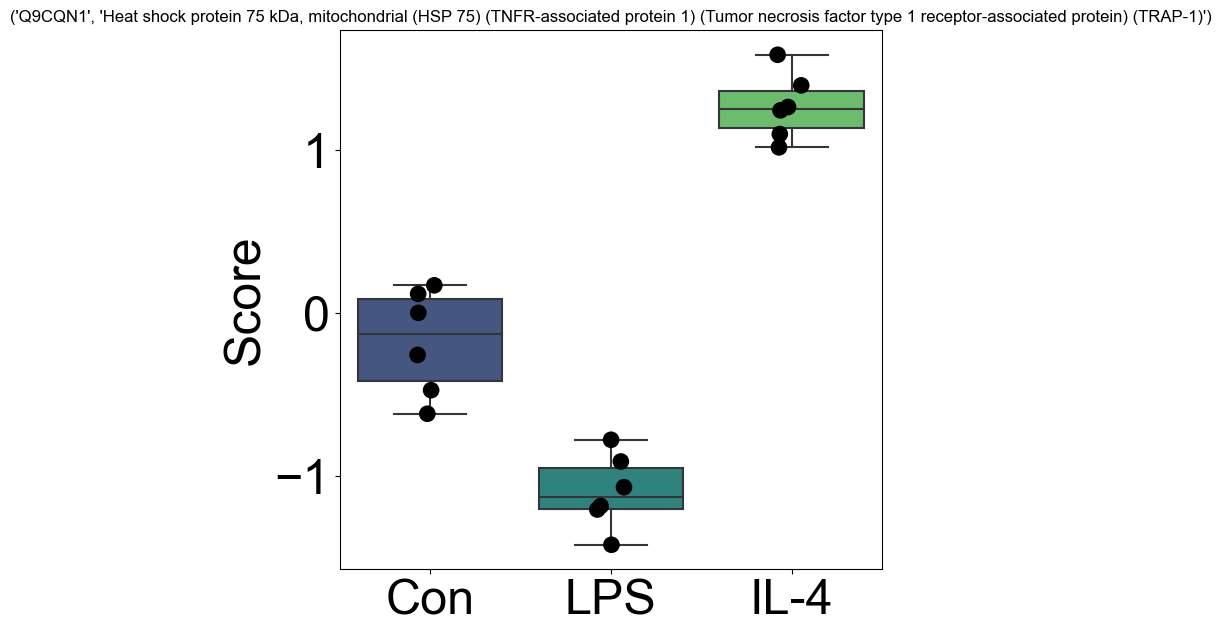

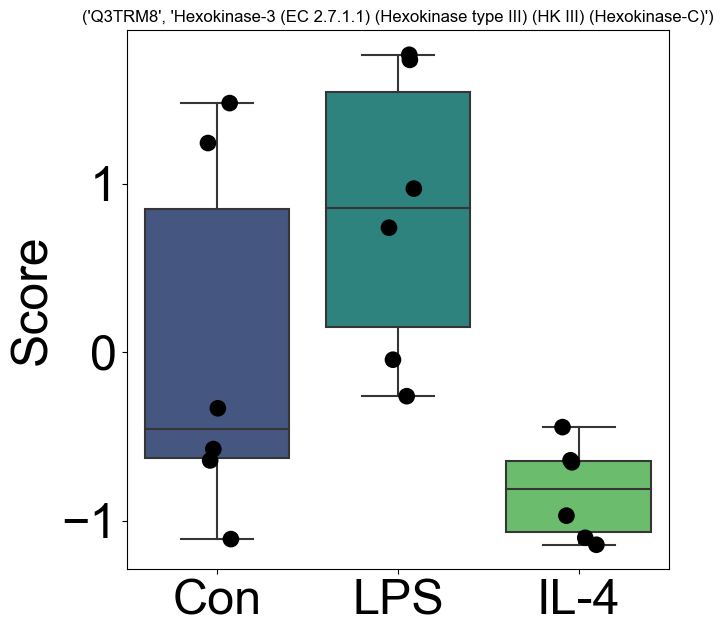

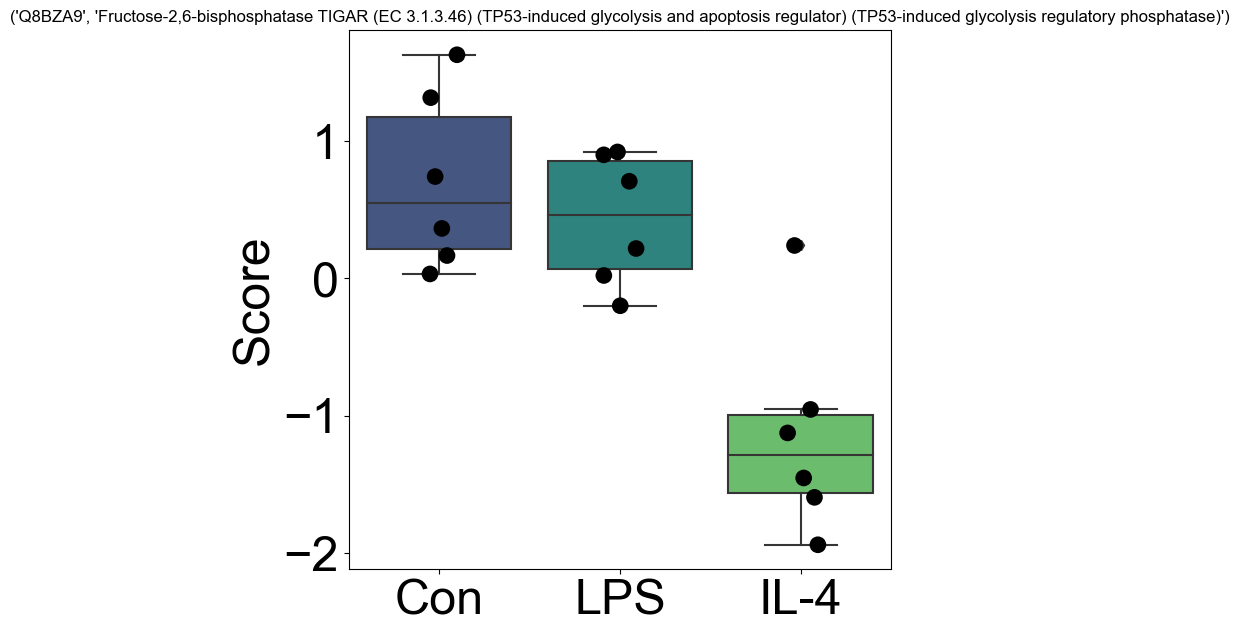

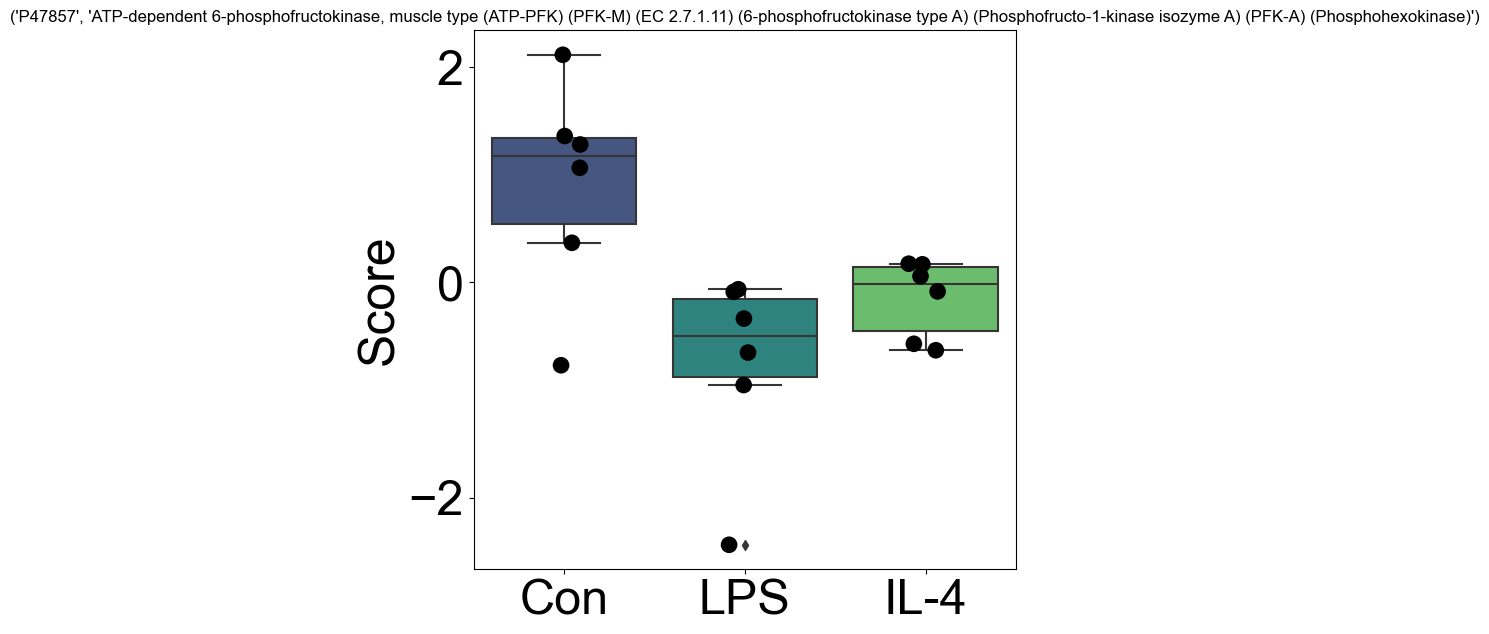

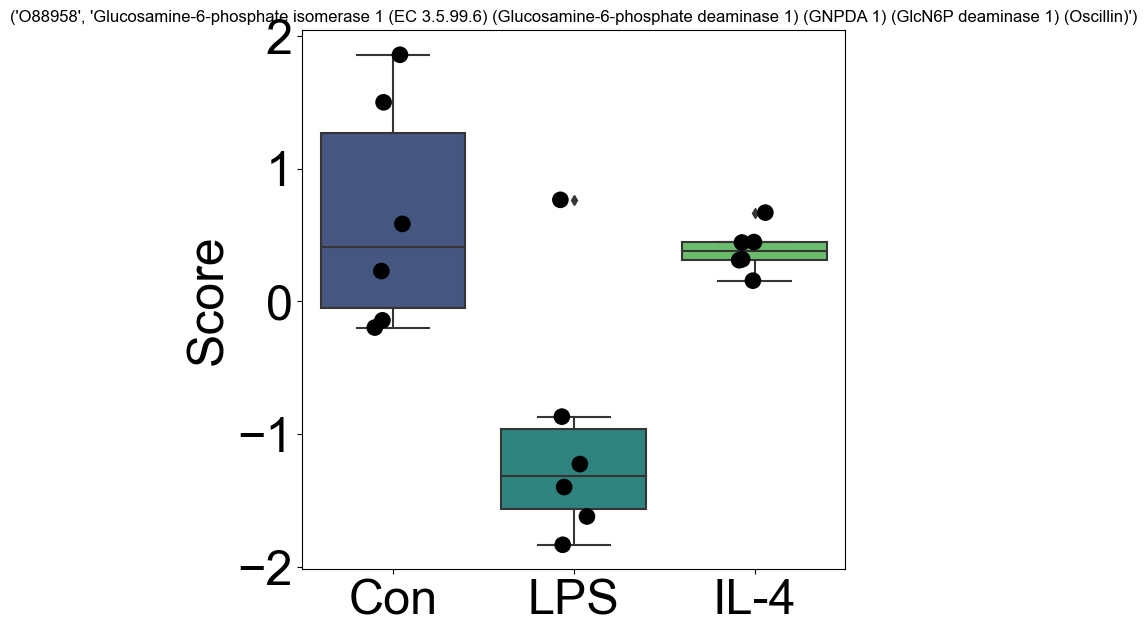

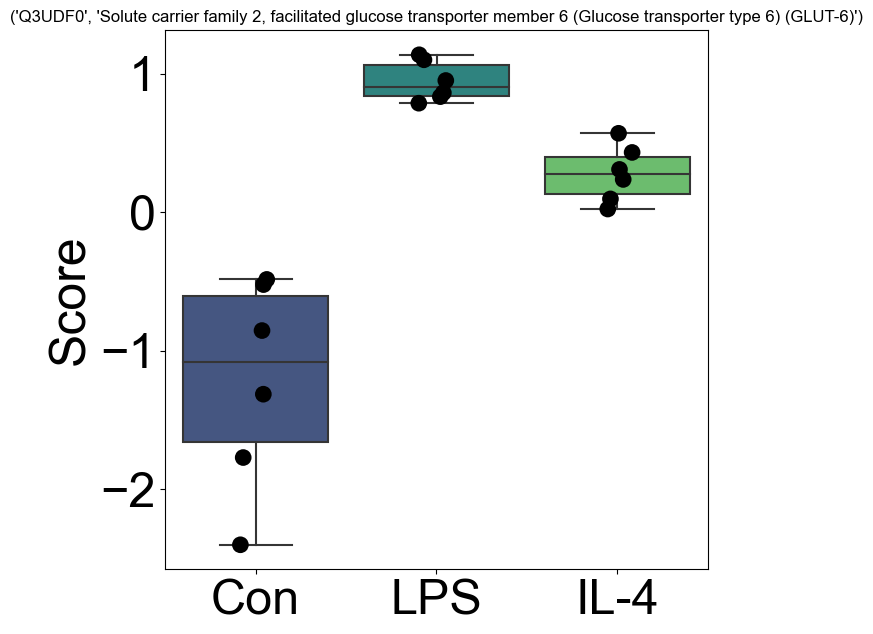

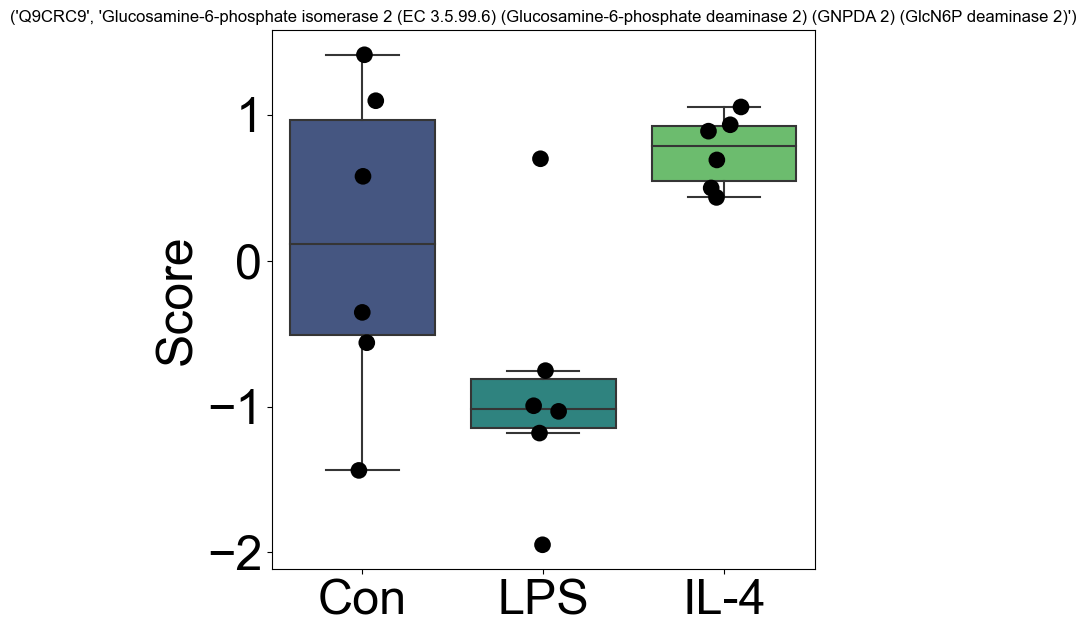

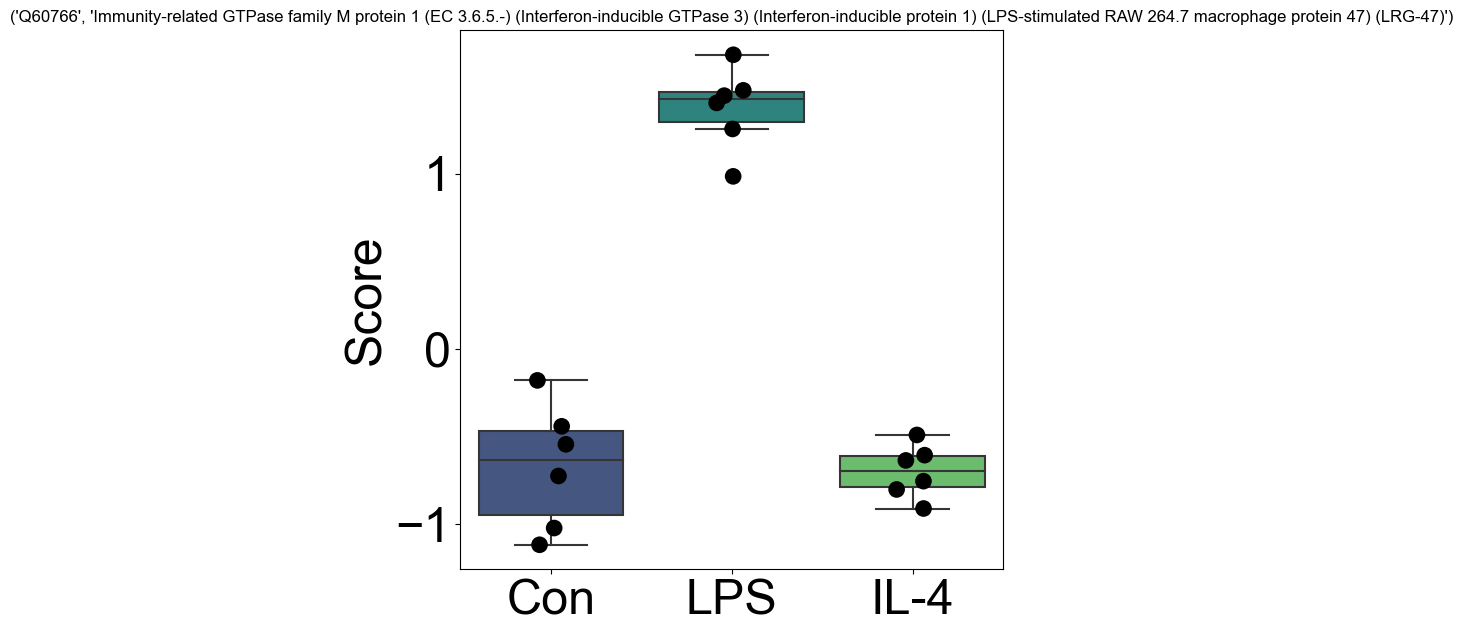

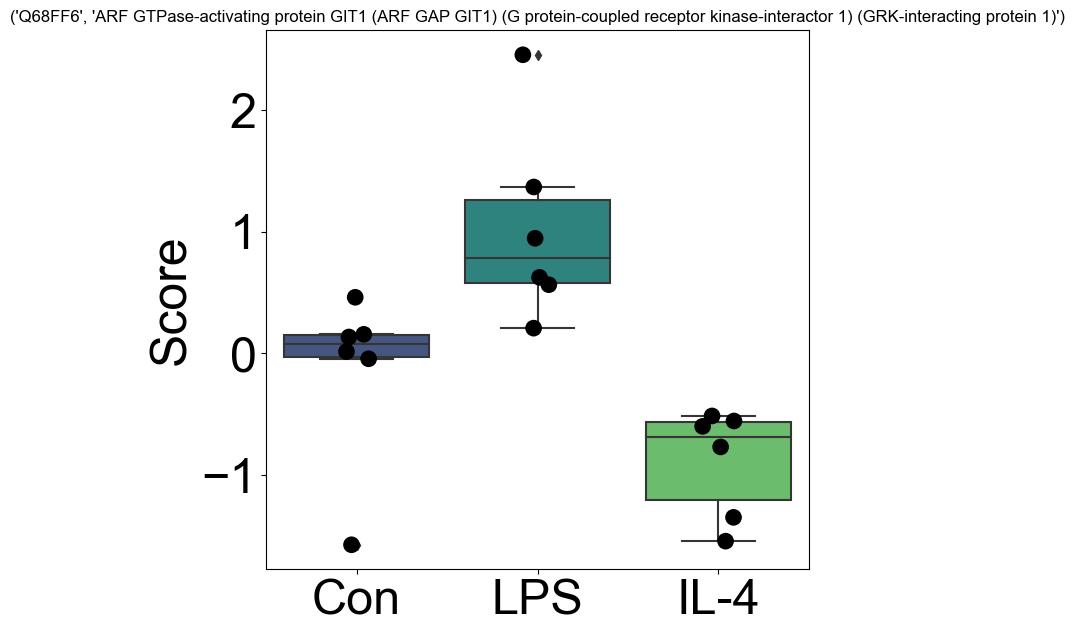

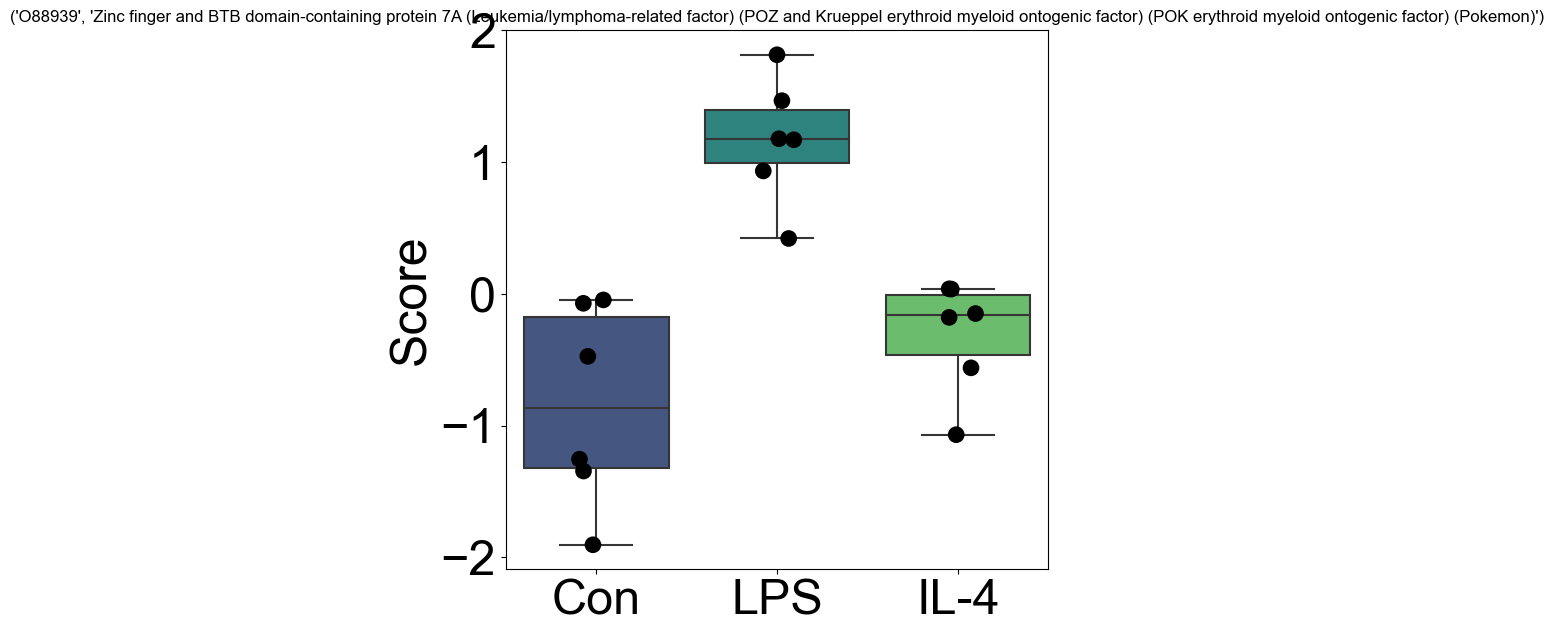

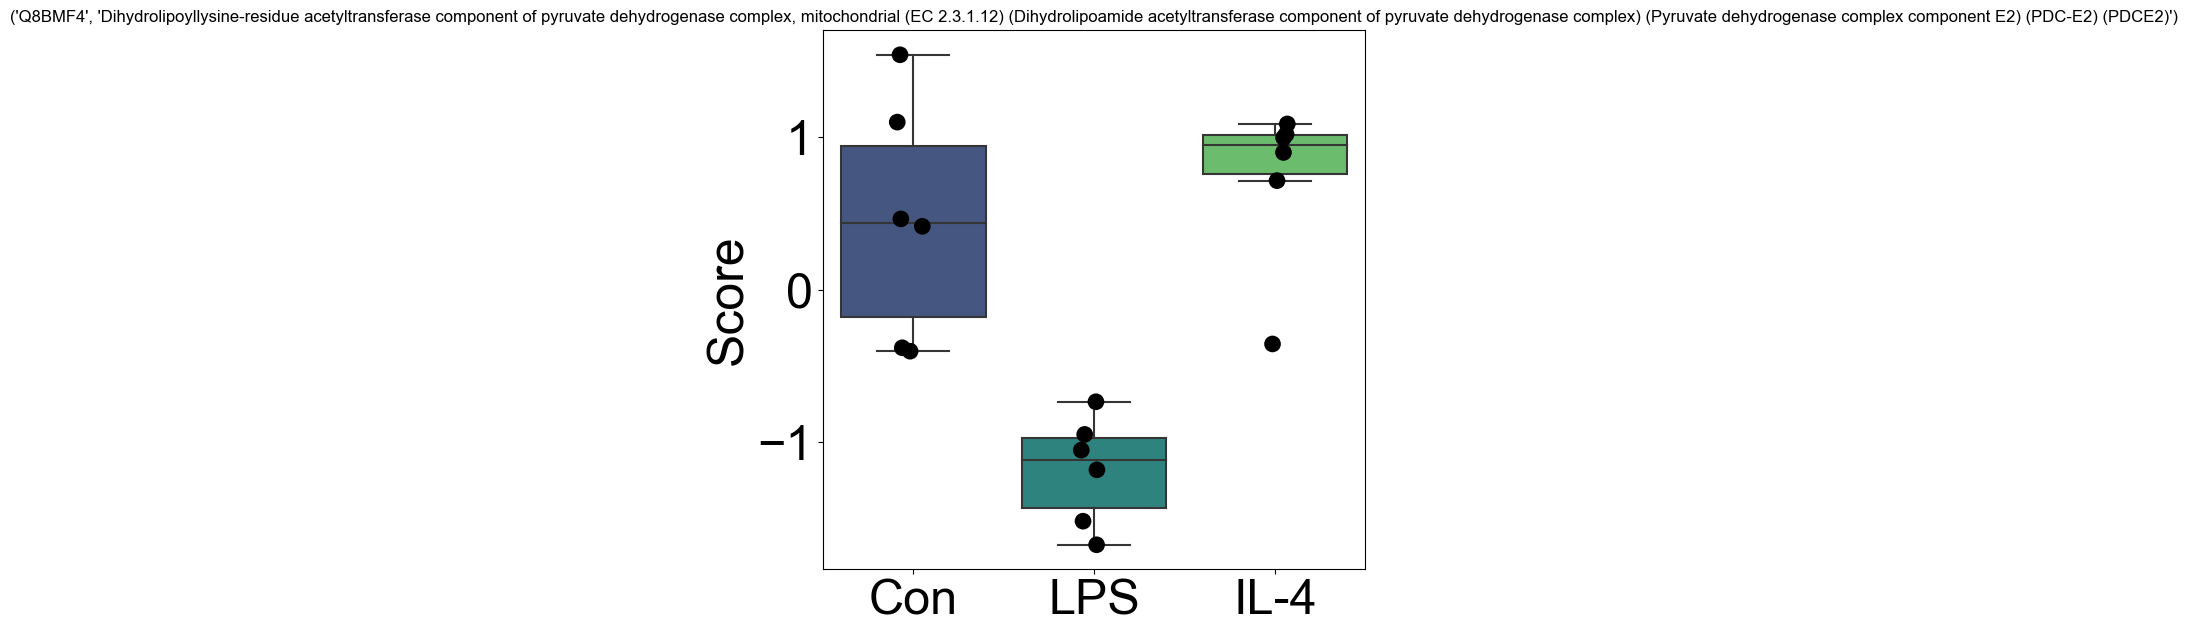

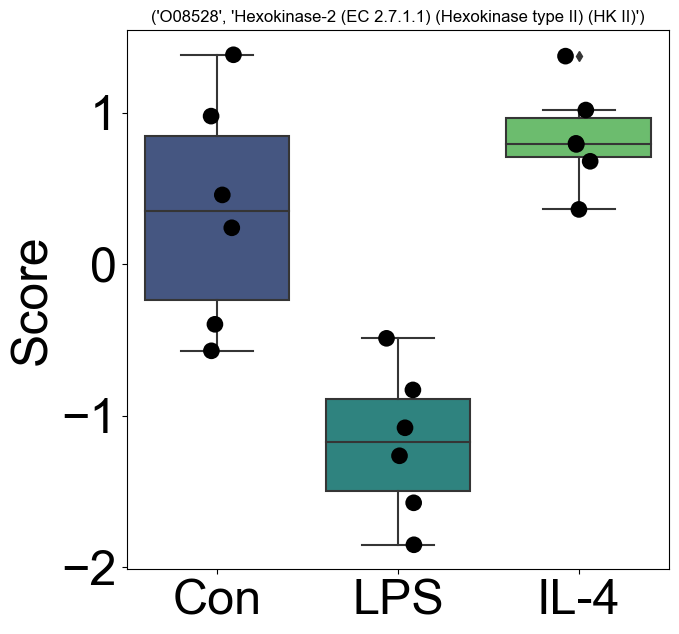

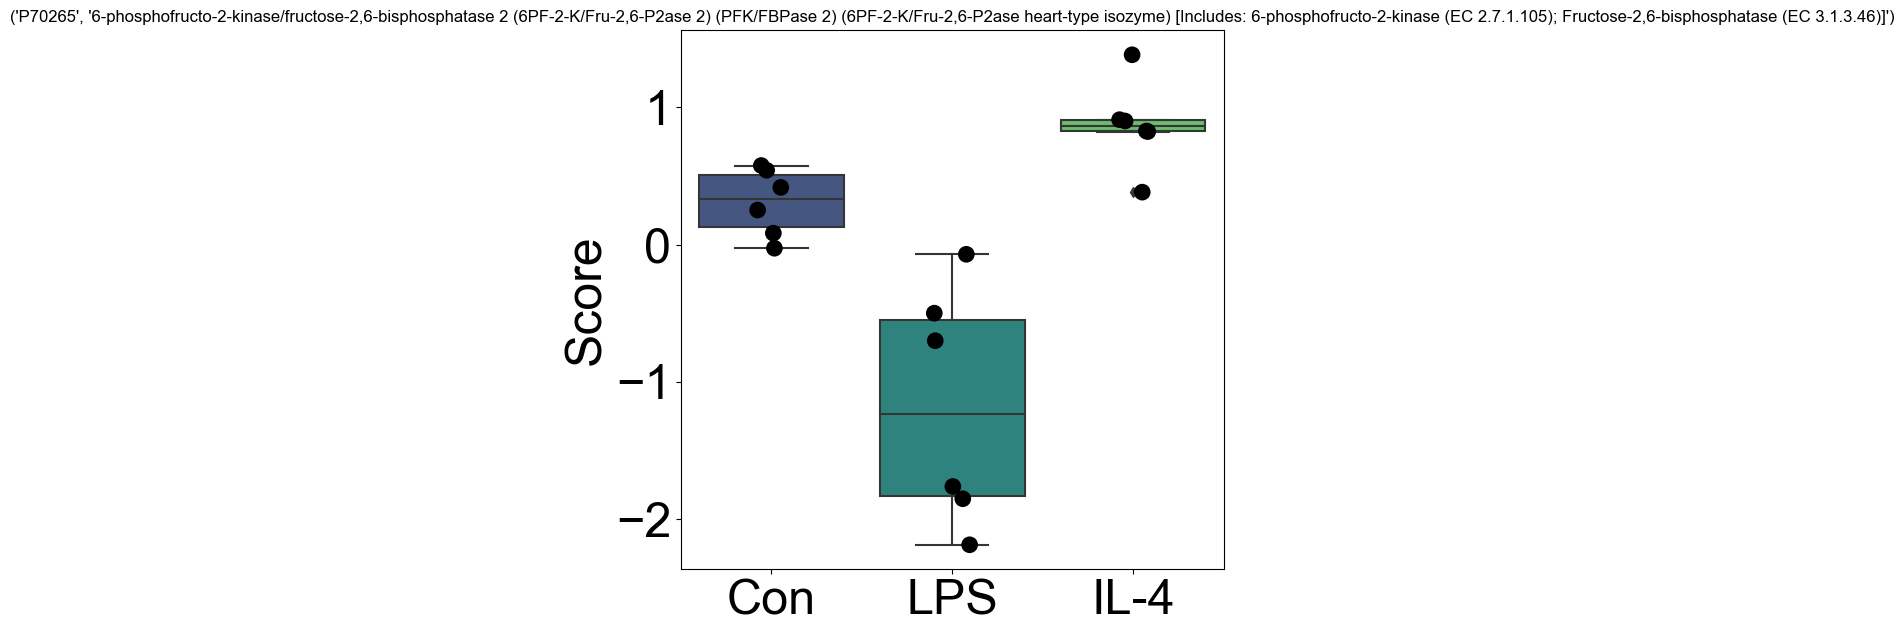

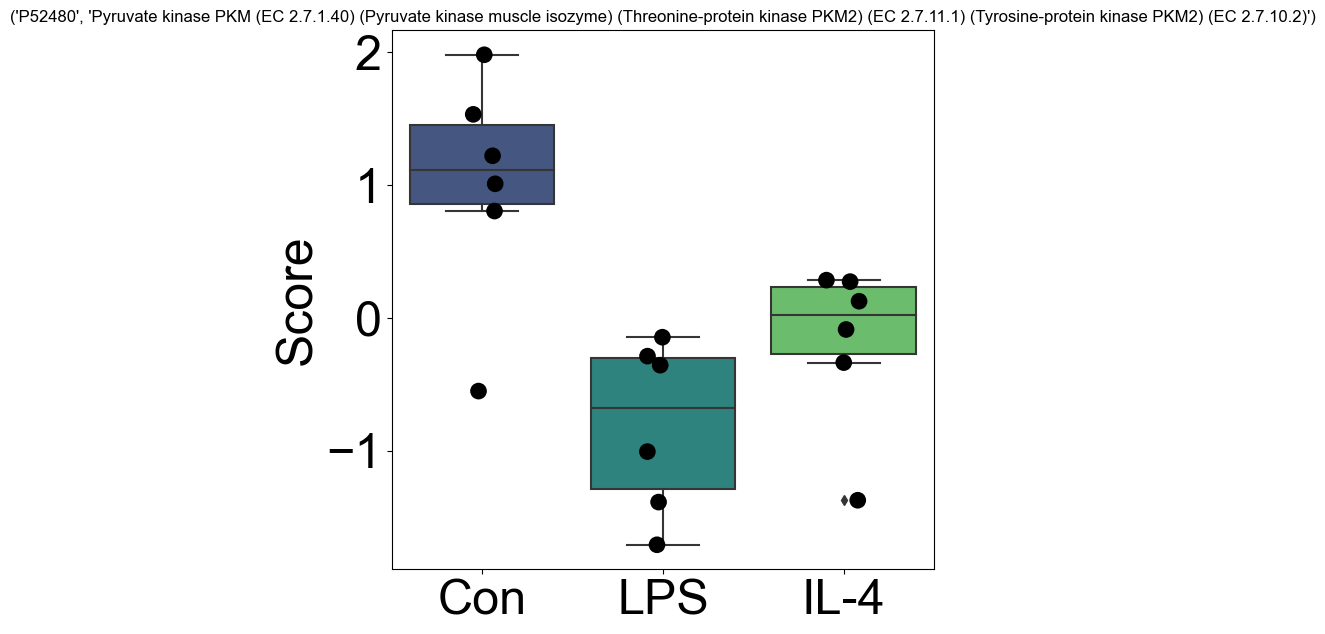

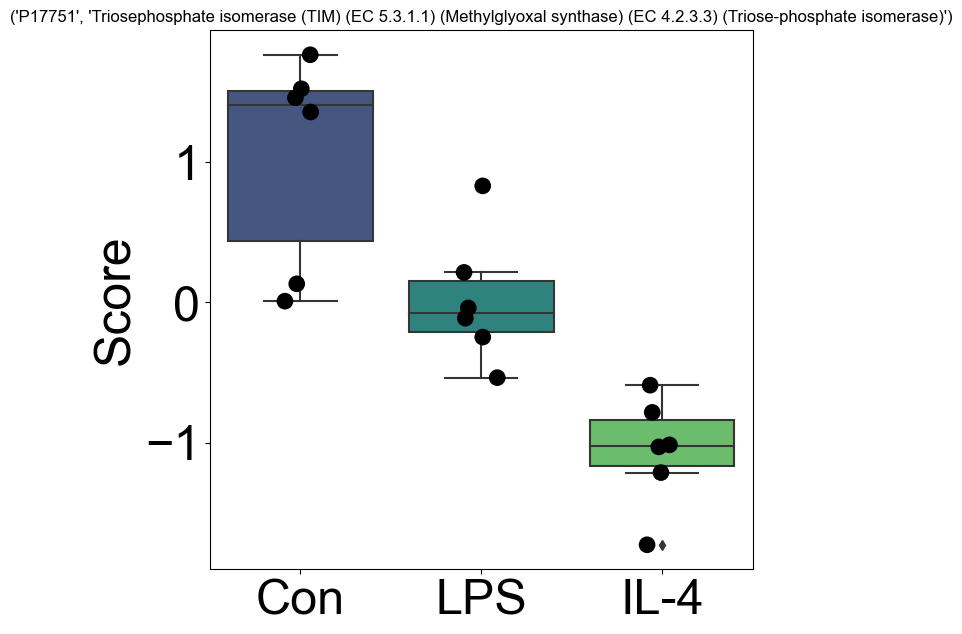

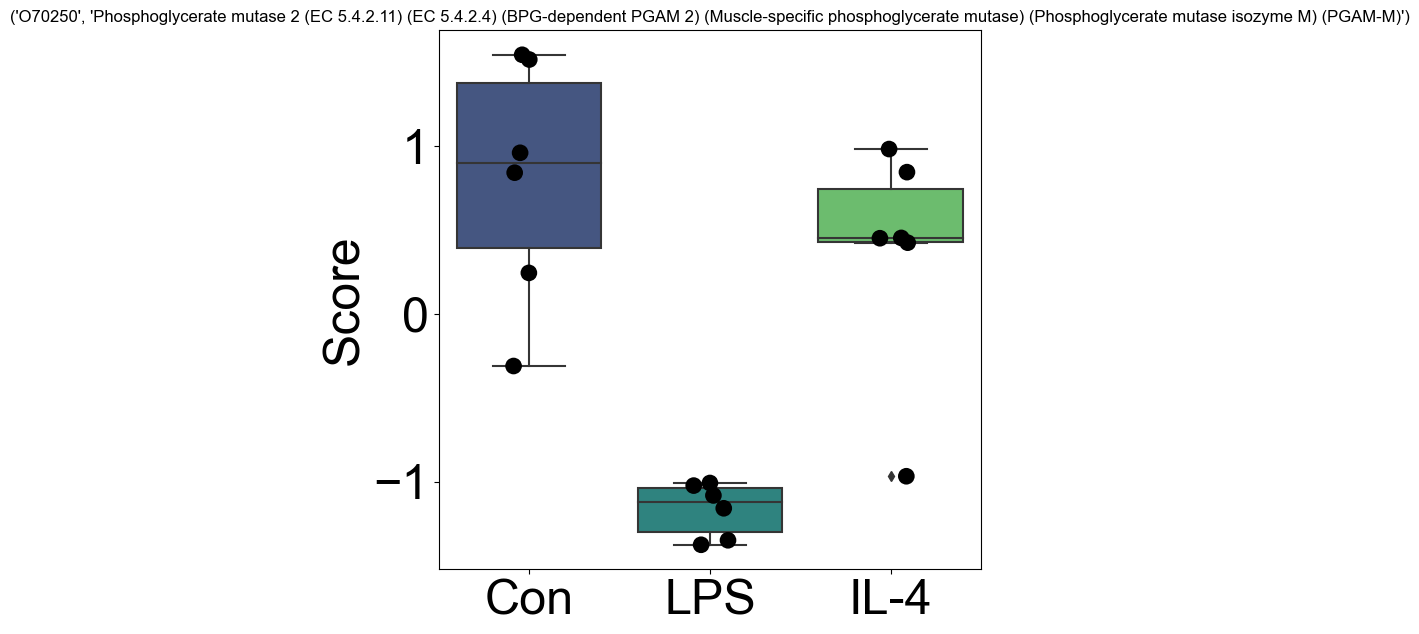

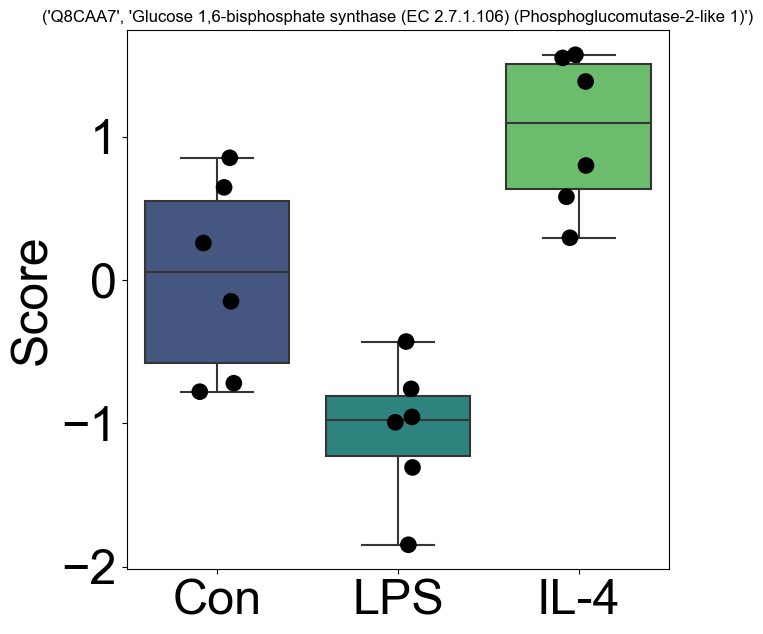

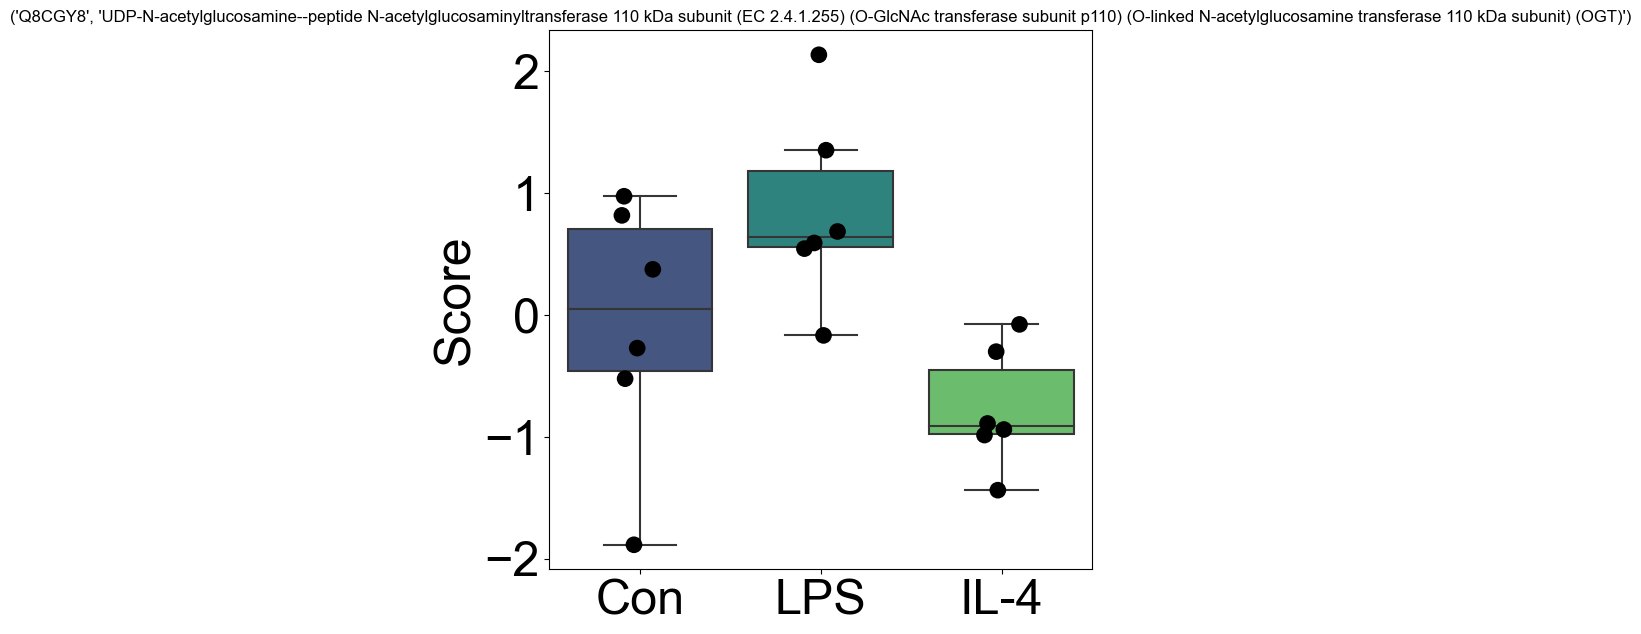

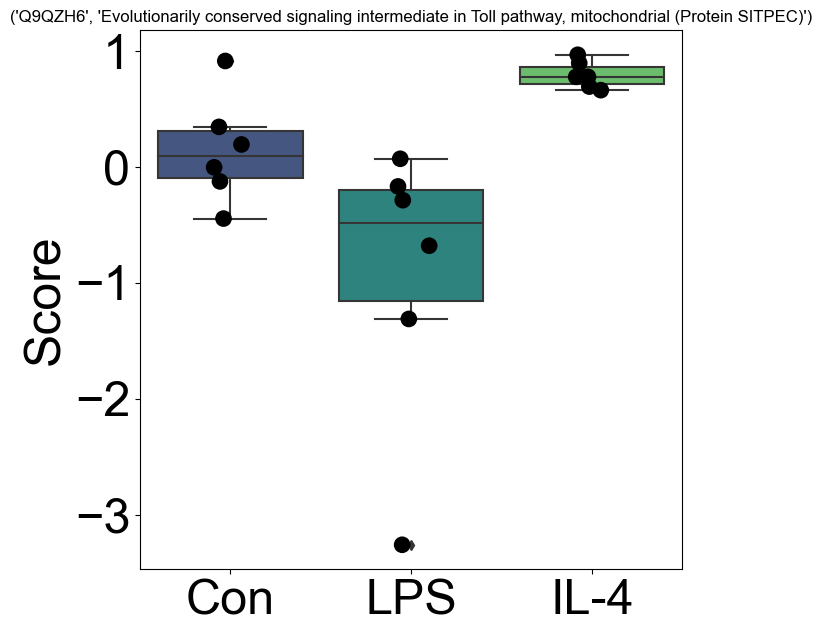

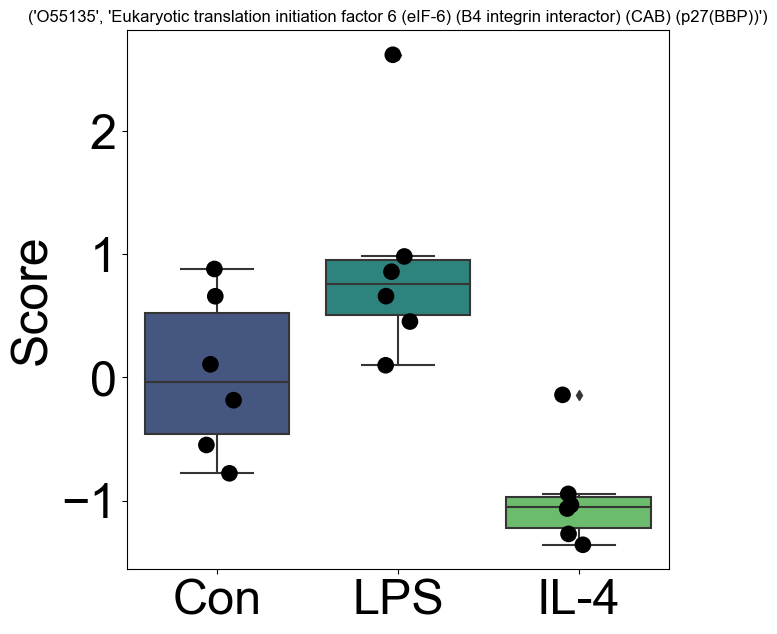

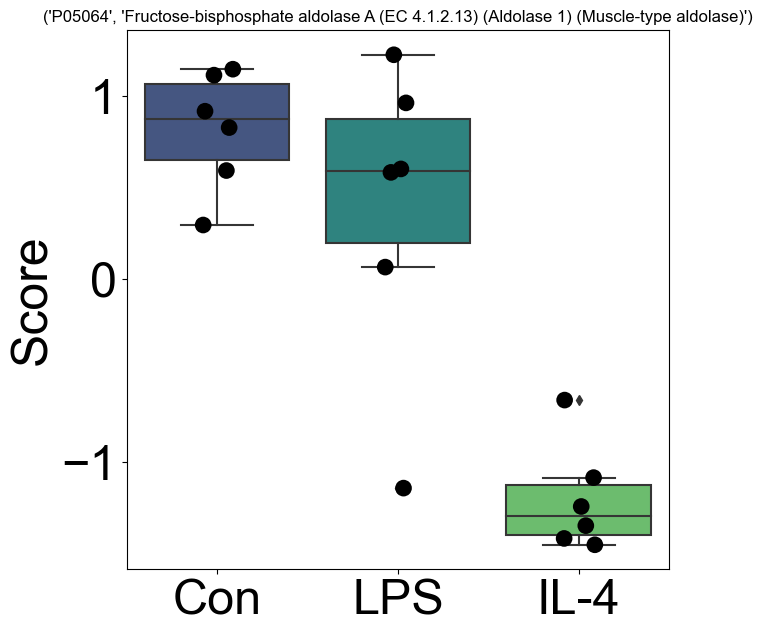

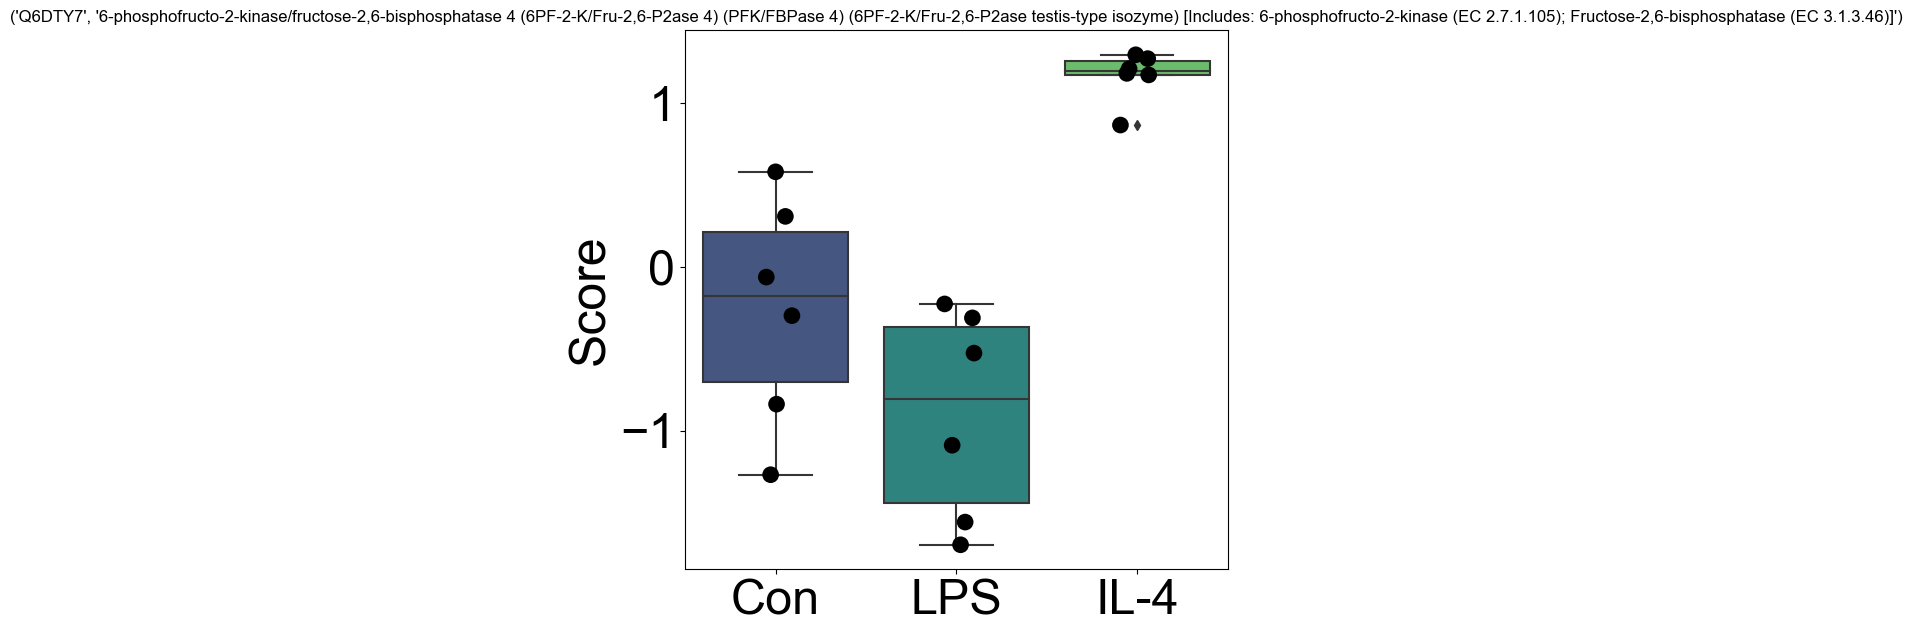

In [118]:


for number in list(overlap):
    plot_fig(number,df_name=dfpro_stdbyrow,
            fig_path = 'C:/Users/jiangy5/Box/macrophage-33files/analysis/figures/')
 